=== Cross-Margin Monte Carlo Simulation Results ===
95% Potential Future Exposure (PFE) on final day: $153.34
Expected Exposure (EE) on final day: $38.72


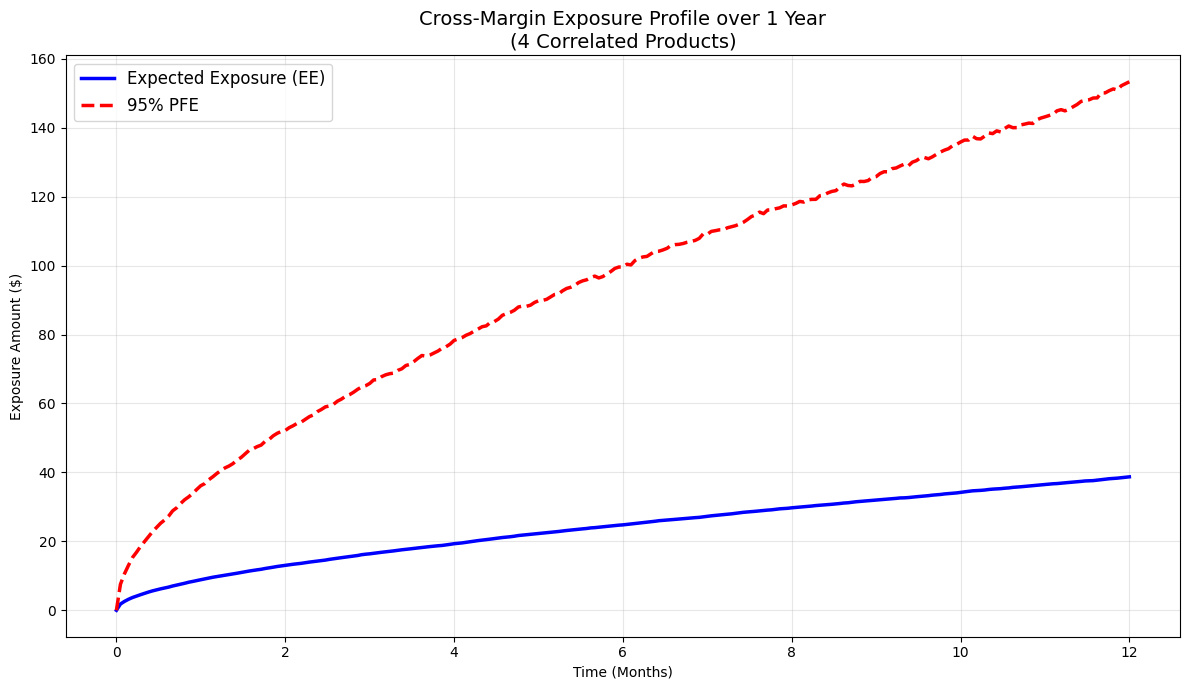

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================
# Monte Carlo Simulation for Cross-Margin 
# Counterparty Credit Risk Modeling
# =============================================

np.random.seed(42)

# Parameters
M = 20000                    # Number of simulation paths
T = 1.0                      # Time horizon in years
N = 252                      # Number of time steps (trading days)
dt = T / N                   # Time step size

# Initial values for 4 products
S0 = np.array([100.0, 100.0, 100.0, 100.0])

# Drift (expected return) and volatility for each product
mu = np.array([0.05, 0.06, 0.04, 0.03])
sigma = np.array([0.25, 0.30, 0.20, 0.22])

# Correlation matrix - Key for Cross-Margin offsetting effect
corr_matrix = np.array([
    [1.00, 0.80, 0.30, -0.20],   # Equity Swap
    [0.80, 1.00, 0.60,  0.10],   # Energy Derivative
    [0.30, 0.60, 1.00,  0.50],   # Metals
    [-0.20, 0.10, 0.50,  1.00]   # Convertible Bonds
])

# Cholesky decomposition for correlated random numbers
L = np.linalg.cholesky(corr_matrix)

# Generate independent standard normal random variables
Z = np.random.normal(0, 1, size=(4, M, N))

# Generate correlated random shocks using Cholesky
Z_corr = np.einsum('ij,jkl->ikl', L, Z)

# Simulate price paths using Geometric Brownian Motion (GBM)
paths = np.zeros((4, M, N + 1))
paths[:, :, 0] = S0[:, np.newaxis]

for t in range(1, N + 1):
    drift = (mu[:, np.newaxis] - 0.5 * sigma[:, np.newaxis]**2) * dt
    diffusion = sigma[:, np.newaxis] * np.sqrt(dt) * Z_corr[:, :, t-1]
    paths[:, :, t] = paths[:, :, t-1] * np.exp(drift + diffusion)

# Calculate portfolio value and exposure at every time step
portfolio_value_over_time = np.sum(paths - S0[:, np.newaxis, np.newaxis], axis=0)
exposure_over_time = np.maximum(portfolio_value_over_time, 0)

# Compute daily risk metrics
daily_EE = np.mean(exposure_over_time, axis=0)
daily_PFE95 = np.percentile(exposure_over_time, 95, axis=0)

# Final day metrics
final_PFE95 = daily_PFE95[-1]
final_EE = daily_EE[-1]

print("=== Cross-Margin Monte Carlo Simulation Results ===")
print(f"95% Potential Future Exposure (PFE) on final day: ${final_PFE95:,.2f}")
print(f"Expected Exposure (EE) on final day: ${final_EE:,.2f}")

# =============================================
# Visualization: Exposure Profile
# =============================================
time_months = np.linspace(0, 12, N + 1)

plt.figure(figsize=(12, 7))
plt.plot(time_months, daily_EE, label='Expected Exposure (EE)', linewidth=2.5, color='blue')
plt.plot(time_months, daily_PFE95, label='95% PFE', linewidth=2.5, color='red', linestyle='--')

plt.title('Cross-Margin Exposure Profile over 1 Year\n(4 Correlated Products)', fontsize=14)
plt.xlabel('Time (Months)')
plt.ylabel('Exposure Amount ($)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()